In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential, Model
from keras.layers import Input, Dense
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from matplotlib import pyplot
from numpy import where

# File path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeB_unsupervise_sim_combined_data.csv"

# Load the data from the CSV file
data = pd.read_csv(csv_file_path)

############################################
# Split the data into features and target
#X = data.drop(columns=['Label'])
#y = data['Label']

# Normalize the data using MinMaxScaler
#scaler = MinMaxScaler()
#X_scaled = scaler.fit_transform(X)
###########################################

# Extract features (X) and target labels (y) from the loaded data
X = data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable
y = data["Label"]  # Replace "target_column_name" with the actual column name for the target variable

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (35328, 1380)
y shape: (35328,)


In [2]:
# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
X_scaled

array([[0.0836993 , 0.13242321, 0.10512434, ..., 0.0529661 , 0.04472693,
        0.04849341],
       [0.04184965, 0.05392491, 0.1175584 , ..., 0.08451036, 0.08709981,
        0.08451036],
       [0.21286489, 0.26211604, 0.2535795 , ..., 0.17396422, 0.17678908,
        0.17208098],
       ...,
       [0.02996642, 0.03788396, 0.09080633, ..., 0.29872881, 0.29755179,
        0.29096045],
       [0.02350814, 0.02866894, 0.03165034, ..., 0.26553672, 0.2596516 ,
        0.26624294],
       [0.01937484, 0.02559727, 0.02788244, ..., 0.17749529, 0.17113936,
        0.18055556]])

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [5]:
#y_train_1 = (y_train == 1)
#y_test_1 = (y_test == 1)

### Apply SMOTE on the Training Data:
#### Use the SMOTE class from the imbalanced-learn library to oversample the minority class in the training data.

In [6]:
# from imblearn.over_sampling import SMOTE

# # Create a SMOTE instance
# smote = SMOTE(random_state=42)

# # Apply SMOTE on the training data
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [7]:
# define pipeline
# over = SMOTE(sampling_strategy=0.1)
# under = RandomUnderSampler(sampling_strategy=0.5)
# steps = [('o', over), ('u', under)]
# pipeline = Pipeline(steps=steps)

In [8]:
# transform the dataset
# X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train, y_train)

In [9]:
# summarize the new class distribution
counter = Counter(y)
print(counter)

Counter({0: 35186, 1: 142})


In [10]:
# # summarize the new class distribution
# counter = Counter(y_train_resampled)
# print(counter)

In [11]:
#y_train_1 = (y_train_resampled == 1)
#y_test_1 = (y_test == 1)

In [12]:
# # summarize the new class distribution
# counter = Counter(y_train_resampled)
# print(counter)

In [13]:
#from sklearn.linear_model import SGDClassifier

#sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
#sgd_clf.fit(X_train, y_train_5)

In [14]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
# Train an MLP Classifier on the resampled data
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=42)
mlp.fit(X_train, y_train)
#mlp = MLPClassifier(random_state=1, max_iter=300).fit(X_train_resampled, y_train_resampled)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=42)

In [15]:
#mlp.predict(X_test[:5, :])
#mlp.predict_proba(X_test[:1])

# Make predictions on the test data
predictions = mlp.predict(X_test)

In [16]:
predictions

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [17]:
mlp.score(X_test, y_test)

0.9964619303707897

In [18]:
from sklearn.model_selection import cross_val_score
cross_val_score(mlp, X_train, y_train, cv=3, scoring="accuracy")

array([0.99617875, 0.99670948, 0.9962845 ])

### Performance Measures For MLP
#### Measuring Accuracy Using Cross-Validation

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# for train_index, test_index in skfolds.split(X_train, y_train):
#     clone_mlp = clone(mlp)
#     X_train_folds = X_train[train_index]
#     y_train_folds = y_train[train_index]
#     X_test_fold = X_train[test_index]
#     y_test_fold = y_train[test_index]

#     clone_mlp.fit(X_train_folds, y_train_folds)
#     y_pred = clone_mlp.predict(X_test_fold)
#     n_correct = sum(y_pred == y_test_fold)
#     print(n_correct / len(y_pred))
    

### Confusion Matrix

In [20]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(mlp, X_train, y_train, cv=3)

In [21]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train, y_train_pred)

array([[28121,    26],
       [   76,    39]], dtype=int64)

In [22]:
y_train_perfect_predictions = y_train  # pretend we reached perfection
confusion_matrix(y_train, y_train_perfect_predictions)

array([[28147,     0],
       [    0,   115]], dtype=int64)

In [23]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score

# Perform cross-validation prediction
#y_train_pred = cross_val_predict(mlp, X_train, y_train, cv=3)

# Calculate metrics
accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_train, y_train_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = tn / (tn + fp)
fpr = fp / (tn + fp)
fnr = fn / (fn + tp)

# Calculate F1-score and AUC
f1_score = 2 * (precision * recall) / (precision + recall)
auc = roc_auc_score(y_train, y_train_pred)

# Print the calculated metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("True Negative Rate (TNR):", tnr)
print("False Positive Rate (FPR):", fpr)
print("False Negative Rate (FNR):", fnr)
print("F1-score:", f1_score)
print("AUC:", auc)


Accuracy: 0.9963909135942255
Precision: 0.6
Recall: 0.3391304347826087
True Negative Rate (TNR): 0.999076278111344
False Positive Rate (FPR): 0.0009237218886559847
False Negative Rate (FNR): 0.6608695652173913
F1-score: 0.43333333333333335
AUC: 0.6691033564469764


### Precision and Recall

In [24]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train, y_train_pred)

0.6

In [25]:
cm = confusion_matrix(y_train, y_train_pred)
cm[1, 1] / (cm[0, 1] + cm[1, 1])

0.6

In [26]:
recall_score(y_train, y_train_pred)

0.3391304347826087

In [27]:
cm[1, 1] / (cm[1, 0] + cm[1, 1])

0.3391304347826087

In [28]:
from sklearn.metrics import f1_score

f1_score(y_train, y_train_pred)

0.43333333333333335

In [29]:
cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)

0.43333333333333335

In [30]:
#y_scores = mlp.decision_function([some_digit])
y_scores = mlp.predict_proba(X_test)
y_scores

# y_scores = sgd_clf.decision_function(X_test)
# y_scores

array([[9.99999007e-01, 9.92886907e-07],
       [1.00000000e+00, 3.59521692e-14],
       [9.99999674e-01, 3.26436317e-07],
       ...,
       [9.99999998e-01, 2.12657303e-09],
       [9.99998148e-01, 1.85177534e-06],
       [1.00000000e+00, 2.52810592e-12]])

In [31]:
threshold = 0
y_scores_pred = (y_scores > threshold)

In [32]:
y_scores_pred 

array([[ True,  True],
       [ True,  True],
       [ True,  True],
       ...,
       [ True,  True],
       [ True,  True],
       [ True,  True]])

In [33]:
threshold = -2
y_scores_pred = (y_scores > threshold)
y_scores_pred

array([[ True,  True],
       [ True,  True],
       [ True,  True],
       ...,
       [ True,  True],
       [ True,  True],
       [ True,  True]])

In [34]:
#from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
#import numpy as np

# Use cross_val_predict to get predicted probabilities
y_probabilities = cross_val_predict(mlp, X_train, y_train, cv=3,
                                     method="predict_proba")

# Assuming the positive class is labeled as 1
y_scores = y_probabilities[:, 1]  # Probability estimates for the positive class

# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

In [35]:
import os
# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "classification"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

In [36]:
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Saving figure HomeB_sim_sgd_precision_recall_vs_threshold_plot


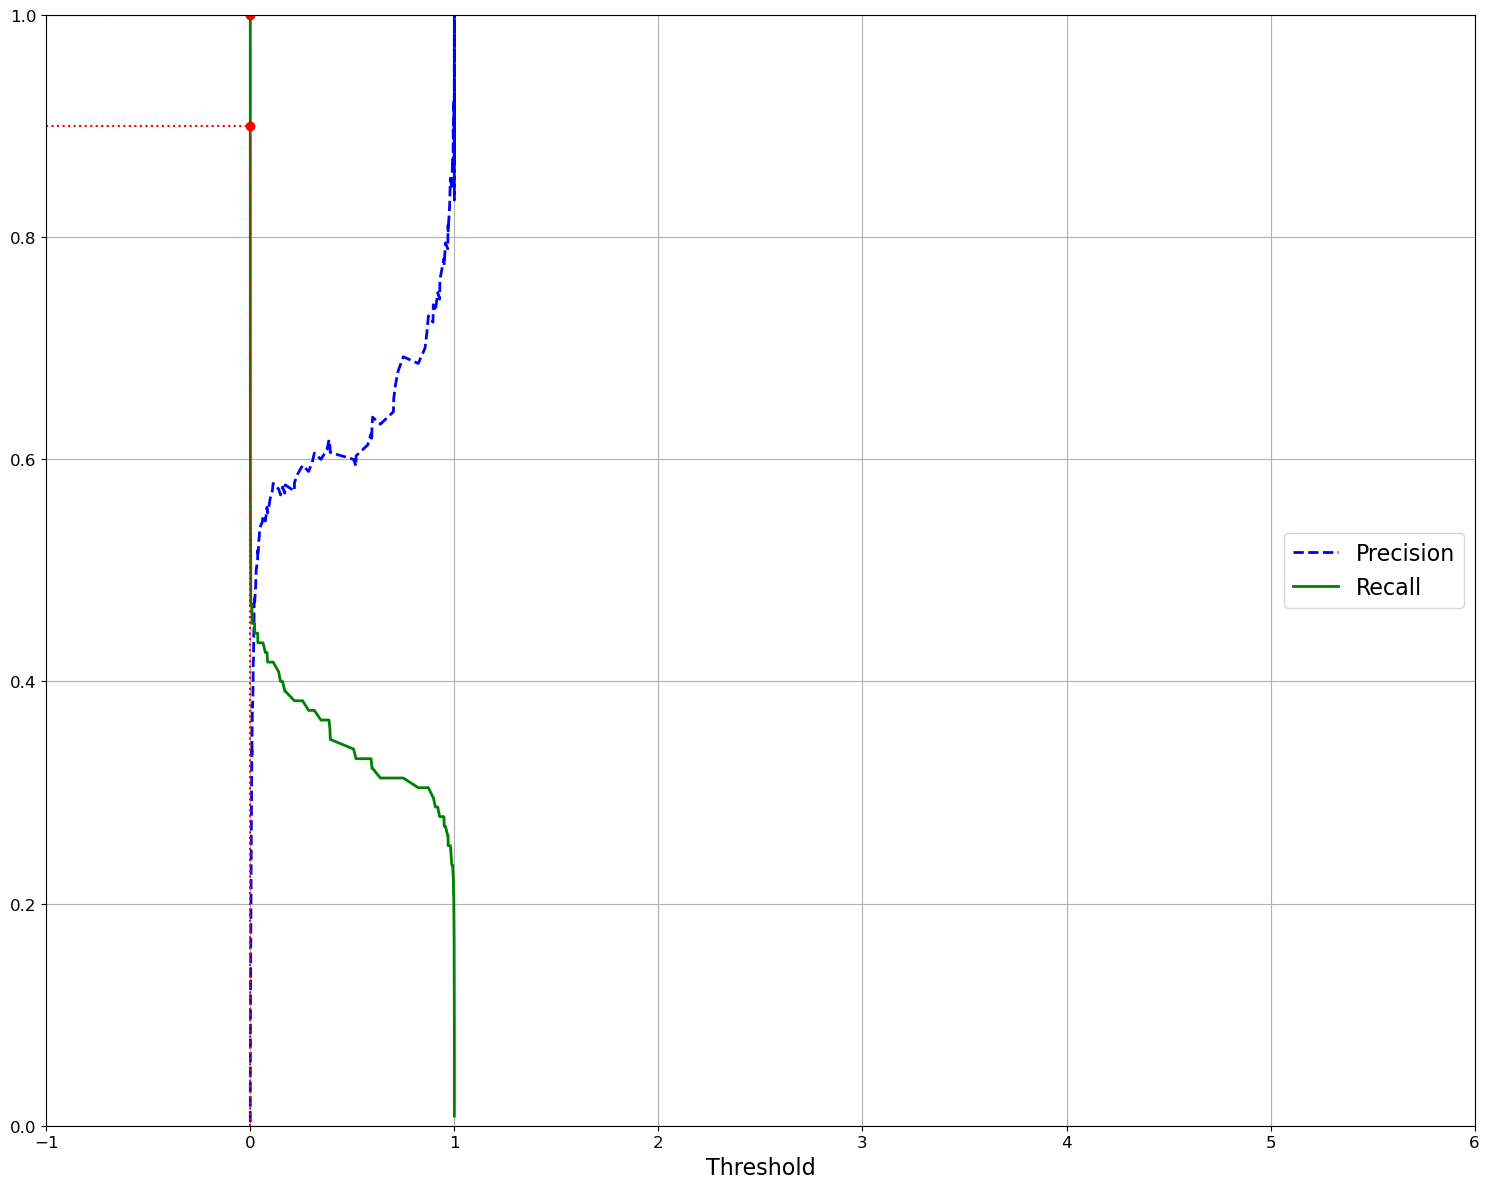

In [38]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=16) # Not shown in the book
    plt.xlabel("Threshold", fontsize=16)        # Not shown
    plt.grid(True)                              # Not shown
    plt.axis([-1, 6, 0, 1])             # Not shown



recall_90_precision = recalls[np.argmax(precisions <= 0.90)]
threshold_90_precision = thresholds[np.argmax(precisions <= 0.90)]
#recall_80_precision = recalls[np.argmax(precisions >= 0.80)]
#threshold_80_precision = thresholds[np.argmax(precisions >= 0.80)]


#plt.figure(figsize=(8, 4))  
plt.figure(figsize=(15, 12))
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")              
plt.plot([-1, threshold_90_precision], [0.9, 0.9], "r:")                                
plt.plot([-1, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")
plt.plot([threshold_90_precision], [0.9], "ro")                                             
plt.plot([threshold_90_precision], [recall_90_precision], "ro")                             
save_fig("HomeB_sim_sgd_precision_recall_vs_threshold_plot")                                              
plt.show()

In [39]:
(y_train_pred == (y_scores > 0)).all()

False

In [40]:
threshold_90_precision

1.986275113762399e-23

Saving figure HomeB_sim_sgd_precision_vs_recall_plot


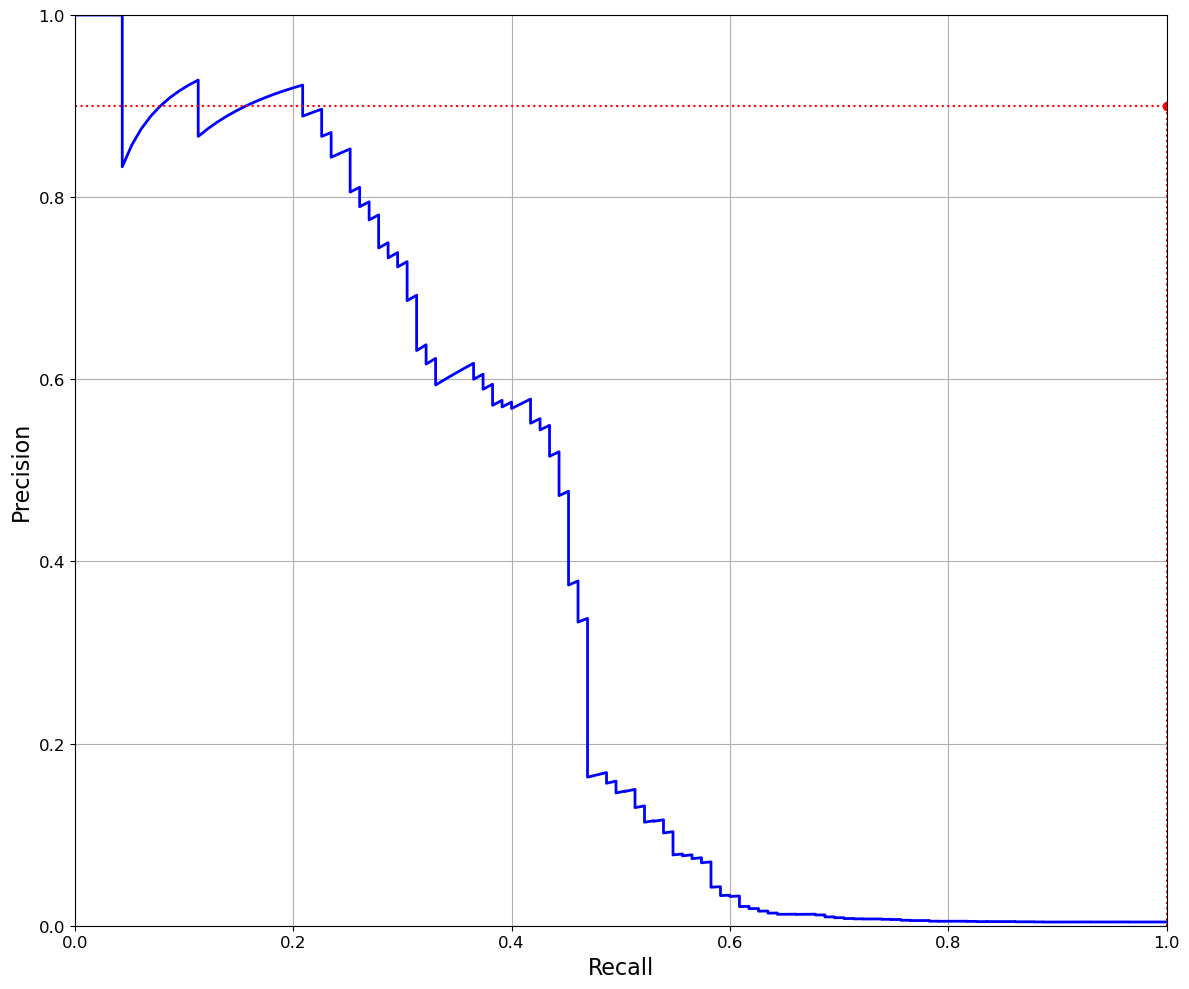

In [41]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

#plt.figure(figsize=(8, 6))
plt.figure(figsize=(12, 10))
plot_precision_vs_recall(precisions, recalls)
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")
save_fig("HomeB_sim_sgd_precision_vs_recall_plot")
plt.show()

In [42]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

In [43]:
threshold_90_precision

0.9970619305152727

In [44]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [45]:
precision_score(y_train, y_train_pred_90)

0.9230769230769231

In [46]:
recall_score(y_train, y_train_pred_90)

0.20869565217391303

In [47]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train, y_scores)

0.757845225609031

### Training SGD Model

In [48]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train, y_train)

SGDClassifier(random_state=42)

In [49]:
# summarize the new class distribution
counter = Counter(y)
print(counter)

Counter({0: 35186, 1: 142})


In [50]:
predictions = sgd_clf.predict(X_test)

In [51]:
predictions

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [52]:
sgd_clf.score(X_test, y_test)

0.9970280215114633

In [53]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.99660333, 0.99702792, 0.99660297])

### Performance Measures For SGD
#### Measuring Accuracy Using Cross-Validation

In [54]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# for train_index, test_index in skfolds.split(X_train, y_train):
#     clone_mlp = clone(mlp)
#     X_train_folds = X_train[train_index]
#     y_train_folds = y_train[train_index]
#     X_test_fold = X_train[test_index]
#     y_test_fold = y_train[test_index]

#     clone_mlp.fit(X_train_folds, y_train_folds)
#     y_pred = clone_mlp.predict(X_test_fold)
#     n_correct = sum(y_pred == y_test_fold)
#     print(n_correct / len(y_pred))

In [55]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)

In [56]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train, y_train_pred)

array([[28129,    18],
       [   74,    41]], dtype=int64)

In [57]:
y_train_perfect_predictions = y_train  # pretend we reached perfection
confusion_matrix(y_train, y_train_perfect_predictions)

array([[28147,     0],
       [    0,   115]], dtype=int64)

In [58]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score

# Perform cross-validation prediction
#y_train_pred = cross_val_predict(mlp, X_train, y_train, cv=3)

# Calculate metrics
accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_train, y_train_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = tn / (tn + fp)
fpr = fp / (tn + fp)
fnr = fn / (fn + tp)

# Calculate F1-score and AUC
f1_score = 2 * (precision * recall) / (precision + recall)
auc = roc_auc_score(y_train, y_train_pred)

# Print the calculated metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("True Negative Rate (TNR):", tnr)
print("False Positive Rate (FPR):", fpr)
print("False Negative Rate (FNR):", fnr)
print("F1-score:", f1_score)
print("AUC:", auc)

Accuracy: 0.9967447455947916
Precision: 0.6949152542372882
Recall: 0.3565217391304348
True Negative Rate (TNR): 0.9993605002309305
False Positive Rate (FPR): 0.0006394997690695279
False Negative Rate (FNR): 0.6434782608695652
F1-score: 0.47126436781609193
AUC: 0.6779411196806826


### Precision and Recall

In [59]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train, y_train_pred)

0.6949152542372882

In [60]:
cm = confusion_matrix(y_train, y_train_pred)
cm[1, 1] / (cm[0, 1] + cm[1, 1])

0.6949152542372882

In [61]:
recall_score(y_train, y_train_pred)

0.3565217391304348

In [62]:
cm[1, 1] / (cm[1, 0] + cm[1, 1])

0.3565217391304348

In [63]:
from sklearn.metrics import f1_score

f1_score(y_train, y_train_pred)

0.47126436781609193

In [64]:
cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)

0.47126436781609193

In [65]:
#y_scores = mlp.decision_function([some_digit])
#y_scores = mlp.predict_proba(X_test)
#y_scores

y_scores = sgd_clf.decision_function(X_test)
y_scores

array([ -8.90885784, -13.92060732, -11.56591224, ...,  -8.46686817,
       -10.73145847,  -6.04211712])

In [66]:
threshold = 0
y_scores_pred = (y_scores > threshold)

In [67]:
y_scores_pred 

array([False, False, False, ..., False, False, False])

In [68]:
threshold = -2
y_scores_pred = (y_scores > threshold)
y_scores_pred

array([False, False, False, ..., False, False, False])

In [69]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train, cv=3,
                             method="decision_function")

In [70]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

In [71]:
import os
# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "classification"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

In [72]:
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Saving figure HomeB_sim_sgd_precision_recall_vs_threshold_plot


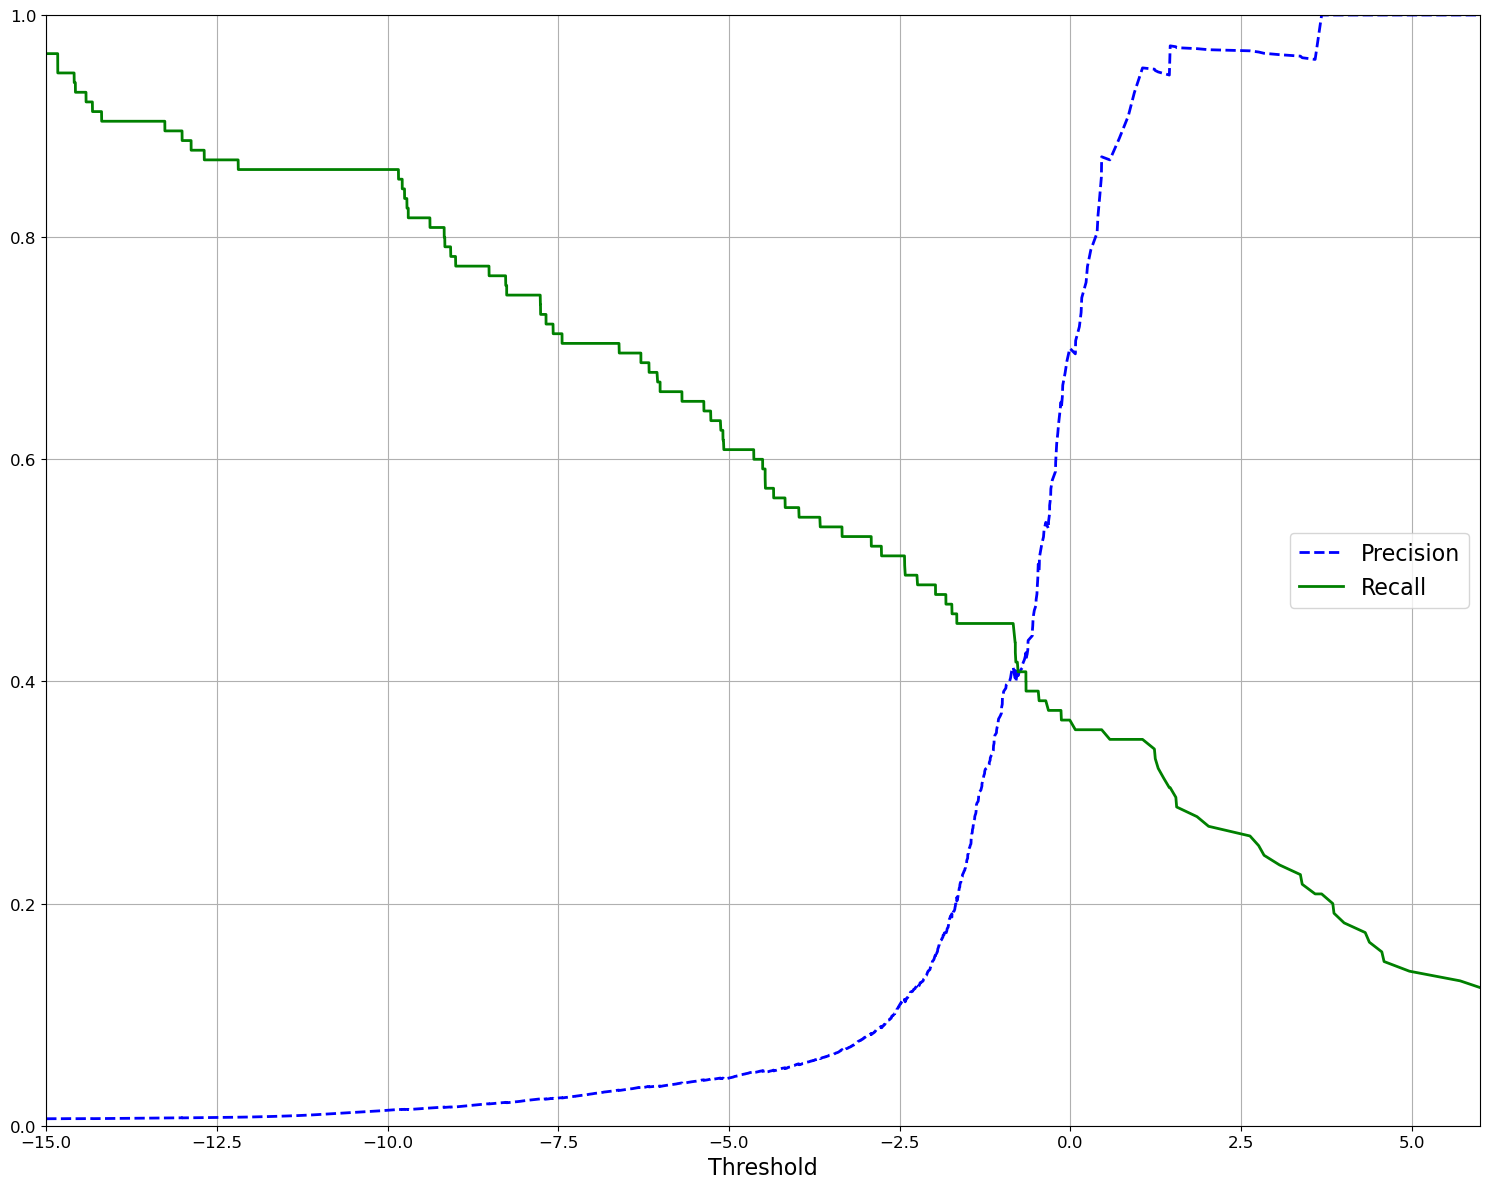

In [74]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=16) # Not shown in the book
    plt.xlabel("Threshold", fontsize=16)        # Not shown
    plt.grid(True)                              # Not shown
    plt.axis([-15, 6, 0, 1])             # Not shown



recall_90_precision = recalls[np.argmax(precisions <= 0.90)]
threshold_90_precision = thresholds[np.argmax(precisions <= 0.90)]
#recall_80_precision = recalls[np.argmax(precisions >= 0.80)]
#threshold_80_precision = thresholds[np.argmax(precisions >= 0.80)]


#plt.figure(figsize=(8, 4))  
plt.figure(figsize=(15, 12))
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")              
plt.plot([-15, threshold_90_precision], [0.9, 0.9], "r:")                                
plt.plot([-15, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")
plt.plot([threshold_90_precision], [0.9], "ro")                                             
plt.plot([threshold_90_precision], [recall_90_precision], "ro")                             
save_fig("HomeB_sim_sgd_precision_recall_vs_threshold_plot")                                              
plt.show()

In [75]:
(y_train_pred == (y_scores > 0)).all()

True

Saving figure HomeB_sim_sgd_precision_vs_recall_plot


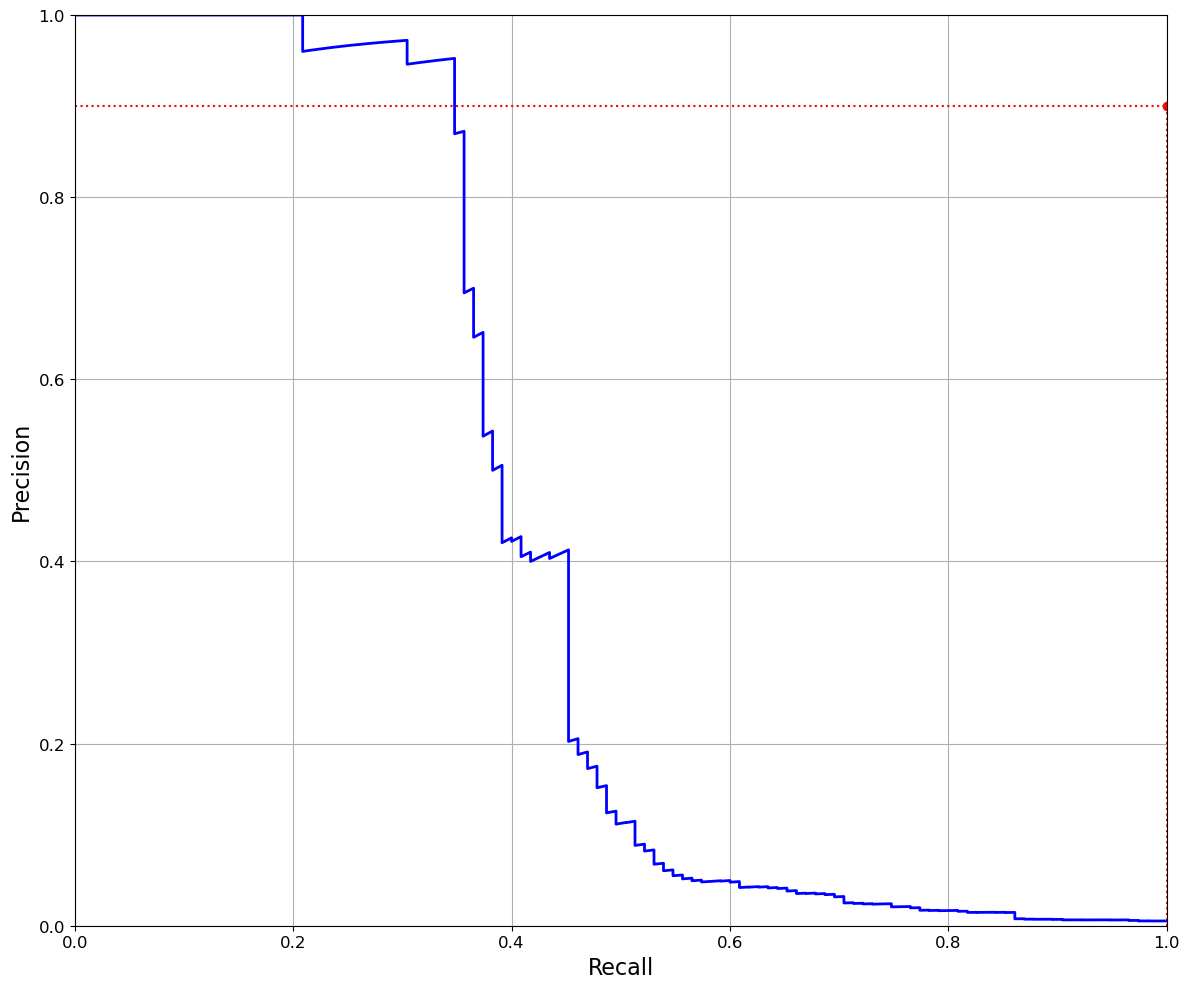

In [76]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

#plt.figure(figsize=(8, 6))
plt.figure(figsize=(12, 10))
plot_precision_vs_recall(precisions, recalls)
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")
save_fig("HomeB_sim_sgd_precision_vs_recall_plot")
plt.show()

In [77]:
threshold_90_precision = thresholds[np.argmax(precisions <= 0.90)]

In [78]:
threshold_90_precision

-16.999999527739085

In [79]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [80]:
precision_score(y_train, y_train_pred_90)

0.0052177858439201455

In [81]:
recall_score(y_train, y_train_pred_90)

1.0

In [82]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train, y_scores)

0.8777143598591864

### Precision/Recall Trade-off

In [83]:
#y_scores = mlp.decision_function([some_digit])
y_scores = mlp.predict_proba(X_test)
y_scores

array([[9.99999007e-01, 9.92886907e-07],
       [1.00000000e+00, 3.59521692e-14],
       [9.99999674e-01, 3.26436317e-07],
       ...,
       [9.99999998e-01, 2.12657303e-09],
       [9.99998148e-01, 1.85177534e-06],
       [1.00000000e+00, 2.52810592e-12]])

In [84]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)

In [85]:
y_some_digit_pred

array([[ True,  True],
       [ True,  True],
       [ True,  True],
       ...,
       [ True,  True],
       [ True,  True],
       [ True,  True]])

In [86]:
threshold = 800
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([[False, False],
       [False, False],
       [False, False],
       ...,
       [False, False],
       [False, False],
       [False, False]])

In [87]:
#from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
#import numpy as np

# Use cross_val_predict to get predicted probabilities
y_probabilities = cross_val_predict(mlp, X_train, y_train, cv=3,
                                     method="predict_proba")

# Assuming the positive class is labeled as 1
y_scores = y_probabilities[:, 1]  # Probability estimates for the positive class

# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)


In [88]:
#y_scores = cross_val_predict(mlp, X_train_resampled, y_train_resampled, cv=3,
#                             method="decision_function")

In [89]:
#from sklearn.metrics import precision_recall_curve

#precisions, recalls, thresholds = precision_recall_curve(y_train_resampled, y_scores)

In [90]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=12) 
    plt.xlabel("Threshold", fontsize=12)        
    plt.grid(True)                              
    plt.axis([-1, 1, 0, 1])             


In [91]:
recall_90_precision = recalls[np.argmax(precisions >= 0.90)]
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

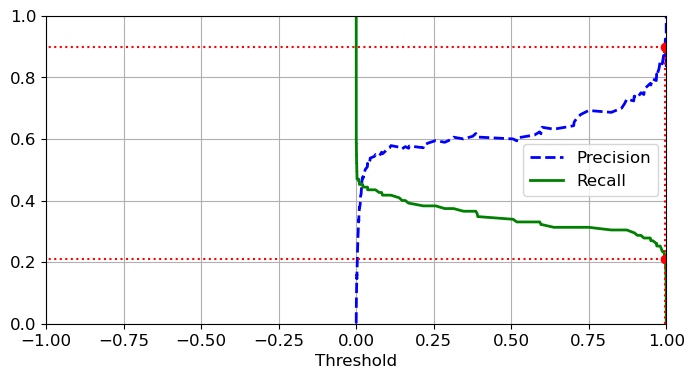

In [92]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))                                                                  
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")                 
plt.plot([-5, threshold_90_precision], [0.9, 0.9], "r:")                                
plt.plot([-5, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")
plt.plot([threshold_90_precision], [0.9], "ro")                                             
plt.plot([threshold_90_precision], [recall_90_precision], "ro")                             
# save_fig("precision_recall_vs_threshold_plot")                                            
# plt.show()
plt.savefig("HomeB_sim_mlp_precision_recall_vs_threshold_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [171]:
(y_train_pred == (y_scores > 0)).all()

False

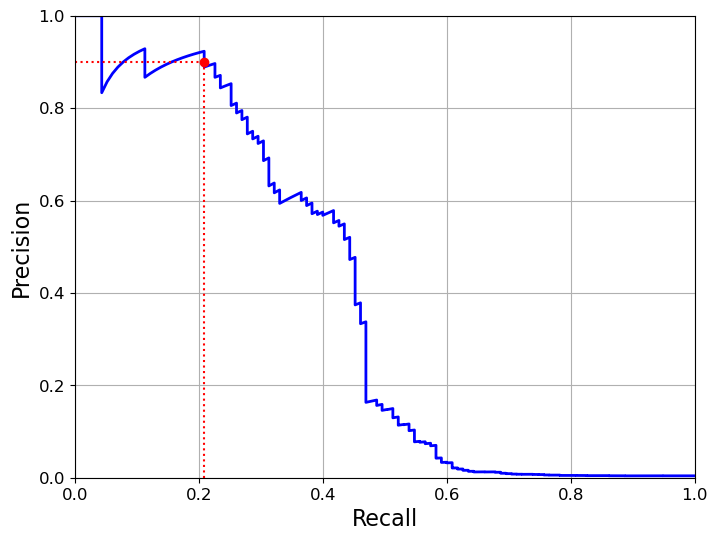

In [93]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")
# save_fig("precision_vs_recall_plot")
# plt.show()
plt.savefig("HomeB_sim_mlp_precision_vs_recall_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [94]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

In [95]:
threshold_90_precision

0.9970619305152727

In [96]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [97]:
precision_score(y_train, y_train_pred_90)

0.9230769230769231

In [98]:
recall_score(y_train, y_train_pred_90)

0.20869565217391303

### The ROC Curve

In [100]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, y_scores)

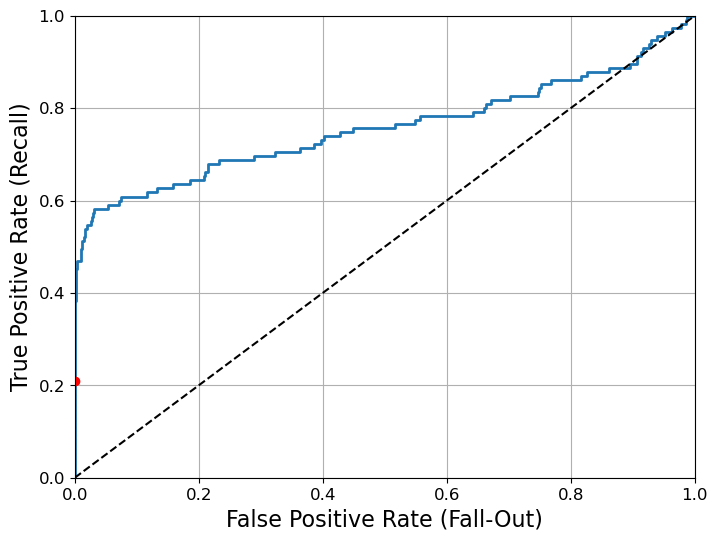

In [101]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    plt.axis([0, 1, 0, 1])                                    
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16) 
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)    
    plt.grid(True)                                            

plt.figure(figsize=(8, 6))                                    
plot_roc_curve(fpr, tpr)
fpr_90 = fpr[np.argmax(tpr >= recall_90_precision)]           
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")   
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")  
plt.plot([fpr_90], [recall_90_precision], "ro")               
# save_fig("roc_curve_plot")                                    
# plt.show()
plt.savefig("HomeB_sim_mlp_roc_curve_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [102]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train, y_scores)

0.757845225609031

### Now let's now train a RandomForestClassifier and compare its ROC curve and ROC AUC score to those of the MLPClassifier.¶

from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train, cv=3,
                                    method="predict_proba")

In [103]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train, cv=3,
                                    method="predict_proba")

In [183]:
#y_probas_forest

In [104]:
forest_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [105]:
# Make predictions on the test data
predictions = forest_clf.predict(X_test)

In [106]:
forest_clf.score(X_test, y_test)

0.9981602037928107

In [107]:
from sklearn.model_selection import cross_val_score
cross_val_score(forest_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.99766479, 0.99777094, 0.99861996])

### Confusion Matrix for Random Forest Classifier
#### Measuring Accuracy Using Cross-Validation

In [108]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(forest_clf, X_train, y_train, cv=3)

In [109]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train, y_train_pred)

array([[28147,     0],
       [   56,    59]], dtype=int64)

In [110]:
y_train_perfect_predictions = y_train  # pretend we reached perfection
confusion_matrix(y_train, y_train_perfect_predictions)

array([[28147,     0],
       [    0,   115]], dtype=int64)

In [111]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score

# Perform cross-validation prediction
#y_train_pred = cross_val_predict(mlp, X_train, y_train, cv=3)

# Calculate metrics
accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_train, y_train_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = tn / (tn + fp)
fpr = fp / (tn + fp)
fnr = fn / (fn + tp)

# Calculate F1-score and AUC
f1_score = 2 * (precision * recall) / (precision + recall)
auc = roc_auc_score(y_train, y_train_pred)

# Print the calculated metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("True Negative Rate (TNR):", tnr)
print("False Positive Rate (FPR):", fpr)
print("False Negative Rate (FNR):", fnr)
print("F1-score:", f1_score)
print("AUC:", auc)


Accuracy: 0.9980185407968296
Precision: 1.0
Recall: 0.5130434782608696
True Negative Rate (TNR): 1.0
False Positive Rate (FPR): 0.0
False Negative Rate (FNR): 0.48695652173913045
F1-score: 0.6781609195402298
AUC: 0.7565217391304349


In [113]:
# from sklearn.metrics import confusion_matrix

# tn, fp, fn, tp = confusion_matrix(y_train, y_train_pred()).ravel()

In [114]:
recall_score(y_train, y_train_pred)

0.5130434782608696

In [115]:
from sklearn.metrics import f1_score

f1_score(y_train, y_train_pred)

0.6781609195402298

In [116]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train, cv=3,
                                    method="predict_proba")

In [117]:
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train,y_scores_forest)

ValueError: x and y must have same first dimension, but have shapes (1,) and (176,)

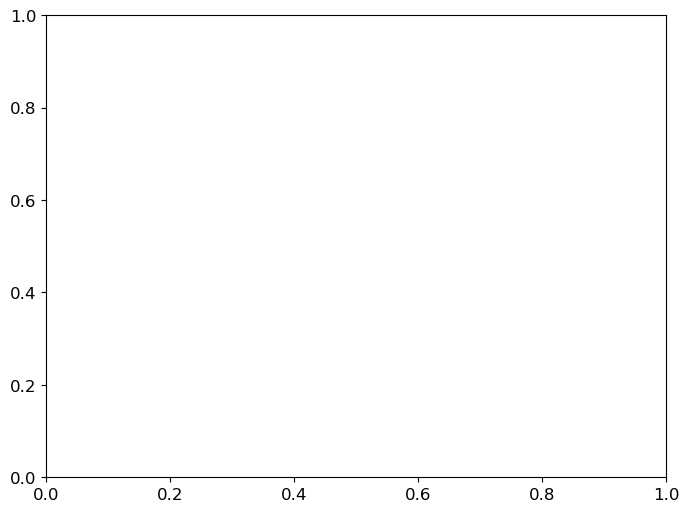

In [121]:
recall_for_forest = tpr_forest[np.argmax(fpr_forest >= fpr_90)]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", linewidth=2, label="MLP")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")
plt.plot([fpr_90], [recall_90_precision], "ro")
plt.plot([fpr_90, fpr_90], [0., recall_for_forest], "r:")
plt.plot([fpr_90], [recall_for_forest], "ro")
plt.grid(True)
plt.legend(loc="lower right", fontsize=12)
# save_fig("roc_curve_comparison_plot")
# plt.show()
plt.savefig("HomeB_sim_rf_roc_curve_comparison_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [123]:
roc_auc_score(y_train, y_scores_forest)

0.9594144715399432

In [124]:
y_train_pred_forest = cross_val_predict(forest_clf, X_train, y_train, cv=3)
precision_score(y_train, y_train_pred_forest)

1.0

In [125]:
recall_score(y_train, y_train_pred_forest)

0.5130434782608696

In [56]:
#sgd_clf.predict([some_digit])
#some_digit = X[0]
#mlp.predict([some_digit])
#mlp.predict()
############################
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
#X, y = make_classification(n_samples=100, random_state=1)
#X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
#                                                     random_state=1)
#clf = MLPClassifier(random_state=1, max_iter=300).fit(X_train, y_train)
#clf.predict_proba(X_test[:1])

#clf.predict(X_test[:5, :])

#clf.score(X_test, y_test)


In [57]:
# Predict the target on the testing data
y_test_pred = mlp.predict(X_test)

In [58]:
pd.crosstab(pd.Series(y_test_pred, name = 'Predicted'),
           pd.Series(y_test, name = 'Actual'))

Actual,0
Predicted,
0,1780
1,346


In [59]:
# Calculate performance metrics
report = classification_report(y_test, y_test_pred, target_names=['class_0', 'class_1'])
roc_auc = roc_auc_score(y_test, y_test_pred)

print("Classification Report:")
print(report)

print("ROC AUC Score:", roc_auc)

#This code uses the resampled data obtained from SMOTE to train an MLP Classifier and then evaluates its performance using various metrics. Note that this example assumes a binary classification problem; if you're dealing with a multi-class problem, you'll need to modify the code accordingly.

Classification Report:
              precision    recall  f1-score   support

     class_0       0.99      0.99      0.99      8777
     class_1       0.97      0.97      0.97      1735

    accuracy                           0.99     10512
   macro avg       0.98      0.98      0.98     10512
weighted avg       0.99      0.99      0.99     10512

ROC AUC Score: 0.9815394177669629


In [ ]:
#print("Number of features in training data:", X.shape[1])
#print("Number of features in test data:", y.shape[1])

In [ ]:
# summarize class distribution
counter = Counter(y)
print(counter)

In [ ]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")

save_fig("some_digit_plot")
plt.show()

In [ ]:
# transform the dataset
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)

In [ ]:
# define pipeline
#over = SMOTE(sampling_strategy=0.1)
#under = RandomUnderSampler(sampling_strategy=0.5)
#steps = [('o', over), ('u', under)]
#pipeline = Pipeline(steps=steps)

In [ ]:
# transform the dataset
#X, y = pipeline.fit_resample(X, y)

In [ ]:
# summarize the new class distribution
counter = Counter(y)
print(counter)

In [ ]:
# Separate the target column (if available) from the training data
# Assuming the target column is the last column (change if not the case)
train_target = train_data.iloc[:, -1]
train_data = train_data.iloc[:, :-1]
#X = train_data.iloc[:, -1]
#y = train_data.iloc[:, :-1]


# Check for missing values in both datasets
#print("Number of missing values in training data:", train_data.isnull().sum().sum())
#print("Number of missing values in test data:", test_data.isnull().sum().sum())

# Store the column names for later use
#column_names = train_data.columns

# Convert non-numeric values to numeric using LabelEncoder
#label_encoder = LabelEncoder()
#for column in train_data.columns:
#    if train_data[column].dtype == 'object':
#        train_data[column] = label_encoder.fit_transform(train_data[column])
#        test_data[column] = label_encoder.transform(test_data[column])

# Ensure the test data has the same set of columns as the training data
#extra_columns = set(test_data.columns) - set(column_names)
#if extra_columns:
#    test_data.drop(columns=extra_columns, inplace=True)

# Handle missing values in the test dataset
#test_data = test_data.fillna(0)  # You can use other imputation techniques based on your data

# Normalize the data using MinMaxScaler
#scaler = MinMaxScaler()
#train_data = scaler.fit_transform(train_data)
#test_data = scaler.transform(test_data)

# Convert back to DataFrames for easy evaluation
#train_data = pd.DataFrame(train_data, columns=column_names)
#test_data = pd.DataFrame(test_data, columns=column_names)


In [ ]:
# Define the MLP-AE model:
def build_autoencoder(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

#input_dim = train_data.shape[1]
input_dim = X_train.shape[1]
autoencoder = build_autoencoder(input_dim)

In [ ]:
# Split the training data into training and validation sets
#X_train, X_val, y_train, y_val = train_test_split(train_data, train_data, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, X_train, test_size=0.2, random_state=42)

In [ ]:
# Train the MLP-AE model with validation data:
history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, validation_data=(X_val, X_val), verbose=0)

In [ ]:
# Access training loss values
training_loss = history.history['loss']
validation_loss = history.history['val_loss']


In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(training_loss) + 1), training_loss, label='Training Loss')
plt.plot(range(1, len(validation_loss) + 1), validation_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
#Use the trained model to make predictions:
train_preds = autoencoder.predict(train_data)
test_preds = autoencoder.predict(test_data)

In [ ]:
#Evaluate the model performance using the specified metrics:
#def evaluate_performance(y_true, y_pred):
#    accuracy = accuracy_score(y_true, y_pred.round())
#    precision = precision_score(y_true, y_pred.round())
#    recall = recall_score(y_true, y_pred.round())
#    tn, fp, fn, tp = confusion_matrix(y_true, y_pred.round()).ravel()
#    tnr = tn / (tn + fp)
#    fpr = fp / (tn + fp)
#    fnr = fn / (fn + tp)
#    f1 = f1_score(y_true, y_pred.round())
#    auc = roc_auc_score(y_true, y_pred)

#    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc
#######################################################################
# Define function for performance evaluation
def evaluate_performance(y_true, y_pred):
    mse = np.mean(np.square(y_true - y_pred), axis=1)
    # Assuming the threshold is 0.5 for anomaly detection (adjust if needed)
    anomaly_preds = (mse > 0.5).astype(int)
    
    accuracy = accuracy_score(y_true, anomaly_preds)
    precision = precision_score(y_true, anomaly_preds)
    recall = recall_score(y_true, anomaly_preds)
    tn, fp, fn, tp = confusion_matrix(y_true, anomaly_preds).ravel()
    tnr = tn / (tn + fp)
    fpr = fp / (tn + fp)
    fnr = fn / (fn + tp)
    f1 = f1_score(y_true, anomaly_preds)
    auc = roc_auc_score(y_true, mse)
    
    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc

#######################################################################

# Assuming your target column is named 'Label' in the test_data DataFrame
test_target = test_data['Label'] if 'Label' in test_data else None
accuracy, precision, recall, tnr, fpr, fnr, f1, auc = evaluate_performance(test_target, test_preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1-score:", f1)
print("AUC:", auc)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential, Model
from keras.layers import Input, Dense

# Load the dataset
train_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Separate the target column (if available) from the training data
# Assuming the target column is the last column (change if not the case)
train_target = train_data.iloc[:, -1]
train_data = train_data.iloc[:, :-1]

# Check for missing values in both datasets
print("Number of missing values in training data:", train_data.isnull().sum().sum())
print("Number of missing values in test data:", test_data.isnull().sum().sum())

# Store the column names for later use
column_names = train_data.columns

# Convert non-numeric values to numeric using LabelEncoder (if any)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in train_data.columns:
    if train_data[column].dtype == 'object':
        train_data[column] = label_encoder.fit_transform(train_data[column])
        test_data[column] = label_encoder.transform(test_data[column])

# Ensure the test data has the same set of columns as the training data
extra_columns = set(test_data.columns) - set(column_names)
if extra_columns:
    test_data.drop(columns=extra_columns, inplace=True)

# Handle missing values in the test dataset
test_data = test_data.fillna(0)  # You can use other imputation techniques based on your data

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

# Define the MLP-AE model:
def build_autoencoder(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

input_dim = train_data.shape[1]
autoencoder = build_autoencoder(input_dim)

# Define function for performance evaluation
def evaluate_performance(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred.round())
    precision = precision_score(y_true, y_pred.round())
    recall = recall_score(y_true, y_pred.round())
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred.round()).ravel()
    tnr = tn / (tn + fp)
    fpr = fp / (tn + fp)
    fnr = fn / (fn + tp)
    f1 = f1_score(y_true, y_pred.round())
    auc = roc_auc_score(y_true, y_pred)
    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc

# Perform k-fold cross-validation and evaluate the model
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_metrics = []

for train_index, val_index in kf.split(train_data):
    X_train, X_val = train_data[train_index], train_data[val_index]
    
    # Assuming your target column is named 'target' in the train_data DataFrame
    y_train, y_val = train_target[train_index], train_target[val_index]
    
    # Assuming your target column is named 'Label' in the train_data DataFrame
    #y_train, y_val = train_Label[train_index], train_Label[val_index]
    
    # Train the MLP-AE model with validation data:
    history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, validation_data=(X_val, X_val), verbose=0)
    
    # Use the trained model to make predictions on the validation data
    val_preds = autoencoder.predict(X_val)
    
    # Evaluate performance on the validation set
    fold_metrics.append(evaluate_performance(y_val, val_preds))

# Calculate the mean and standard deviation of metrics across folds
mean_metrics = np.mean(fold_metrics, axis=0)
std_metrics = np.std(fold_metrics, axis=0)

print("Mean Metrics:")
print("Accuracy:", mean_metrics[0])
print("Precision:", mean_metrics[1])
print("Recall:", mean_metrics[2])
print("TNR:", mean_metrics[3])
print("FPR:", mean_metrics[4])
print("FNR:", mean_metrics[5])
print("F1-score:", mean_metrics[6])
print("AUC:", mean_metrics[7])

print("\nStandard Deviation of Metrics:")
print("Accuracy:", std_metrics[0])
print("Precision:", std_metrics[1])
print("Recall:", std_metrics[2])
print("TNR:", std_metrics[3])
print("FPR:", std_metrics[4])
print("FNR:", std_metrics[5])
print("F1-score:", std_metrics[6])
print("AUC:", std_metrics[7])


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential, Model
from keras.layers import Input, Dense

# Load the dataset
train_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Separate the target column from the training data
train_target = train_data['Label']
train_data = train_data.drop(columns=['Label'])

# Check for missing values in both datasets
print("Number of missing values in training data:", train_data.isnull().sum().sum())
print("Number of missing values in test data:", test_data.isnull().sum().sum())

# Store the column names for later use
column_names = train_data.columns

# Convert non-numeric values to numeric using LabelEncoder (if any)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in train_data.columns:
    if train_data[column].dtype == 'object':
        train_data[column] = label_encoder.fit_transform(train_data[column])
        test_data[column] = label_encoder.transform(test_data[column])
        
# Ensure the test data has the same set of columns as the training data
extra_columns = set(test_data.columns) - set(column_names)
if extra_columns:
    test_data.drop(columns=extra_columns, inplace=True)

# Handle missing values in the test dataset
test_data = test_data.fillna(0)  # You can use other imputation techniques based on your data

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

# Define the MLP-AE model:
def build_autoencoder(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

input_dim = train_data.shape[1]
autoencoder = build_autoencoder(input_dim)

# Define function for performance evaluation
def evaluate_performance(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred.round())
    precision = precision_score(y_true, y_pred.round())
    recall = recall_score(y_true, y_pred.round())
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred.round()).ravel()
    tnr = tn / (tn + fp)
    fpr = fp / (tn + fp)
    fnr = fn / (fn + tp)
    f1 = f1_score(y_true, y_pred.round())
    auc = roc_auc_score(y_true, y_pred)
    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc

# Perform k-fold cross-validation and evaluate the model
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_metrics = []

for train_index, val_index in kf.split(train_data):
    X_train, X_val = train_data[train_index], train_data[val_index]
    y_train, y_val = train_target[train_index], train_target[val_index]
    
    # Train the MLP-AE model with validation data:
    history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, validation_data=(X_val, X_val), verbose=0)
    
    # Use the trained model to make predictions on the validation data
    val_preds = autoencoder.predict(X_val)
    
    # Evaluate performance on the validation set
    fold_metrics.append(evaluate_performance(y_val, val_preds))

# Calculate the mean and standard deviation of metrics across folds
mean_metrics = np.mean(fold_metrics, axis=0)
std_metrics = np.std(fold_metrics, axis=0)

print("Mean Metrics:")
print("Accuracy:", mean_metrics[0])
print("Precision:", mean_metrics[1])
print("Recall:", mean_metrics[2])
print("TNR:", mean_metrics[3])
print("FPR:", mean_metrics[4])
print("FNR:", mean_metrics[5])
print("F1-score:", mean_metrics[6])
print("AUC:", mean_metrics[7])

print("\nStandard Deviation of Metrics:")
print("Accuracy:", std_metrics[0])
print("Precision:", std_metrics[1])
print("Recall:", std_metrics[2])
print("TNR:", std_metrics[3])
print("FPR:", std_metrics[4])
print("FNR:", std_metrics[5])
print("F1-score:", std_metrics[6])
print("AUC:", std_metrics[7])


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential
from keras.layers import Dense

# Load the dataset
train_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Separate the target column from the training data
train_target = train_data['Label']
train_data = train_data.drop(columns=['Label'])

# Check for missing values in both datasets
print("Number of missing values in training data:", train_data.isnull().sum().sum())
print("Number of missing values in test data:", test_data.isnull().sum().sum())

# Store the column names for later use
column_names = train_data.columns

# Convert non-numeric values to numeric using LabelEncoder (if any)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in train_data.columns:
    if train_data[column].dtype == 'object':
        train_data[column] = label_encoder.fit_transform(train_data[column])
        test_data[column] = label_encoder.transform(test_data[column])
        
# Ensure the test data has the same set of columns as the training data
extra_columns = set(test_data.columns) - set(column_names)
if extra_columns:
    test_data.drop(columns=extra_columns, inplace=True)

# Handle missing values in the test dataset
test_data = test_data.fillna(0)  # You can use other imputation techniques based on your data

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

# Define the MLP-AE model:
def build_autoencoder(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

input_dim = train_data.shape[1]
autoencoder = build_autoencoder(input_dim)



In [ ]:
# Perform k-fold cross-validation and evaluate the model
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_metrics = []

for train_index, val_index in kf.split(train_data):
    X_train, X_val = train_data[train_index], train_data[val_index]
    y_train, y_val = train_target[train_index], train_target[val_index]
    
    # Train the MLP-AE model with validation data:
    history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, validation_data=(X_val, X_val), verbose=0)
    
    # Use the trained model to make predictions on the validation data
    val_preds = autoencoder.predict(X_val)
    
    # Calculate the mean squared error (MSE) between the true input and the autoencoder's output
    mse = np.mean(np.square(X_val - val_preds), axis=1)
    
    # Calculate the threshold for anomaly detection as the 95th percentile of MSE values
    threshold = np.percentile(mse, 95)
    
    # Perform anomaly detection based on the threshold
    anomaly_preds = (mse > threshold).astype(int)
    
###############################################################################
# Define function for performance evaluation
#def evaluate_performance(y_true, y_pred):
#    accuracy = accuracy_score(y_true, y_pred)
#    precision = precision_score(y_true, y_pred)
#    recall = recall_score(y_true, y_pred)
#    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
#    tnr = tn / (tn + fp)
#    fpr = fp / (tn + fp)
#    fnr = fn / (fn + tp)
#    f1 = f1_score(y_true, y_pred)
#    
#    # Calculate AUC if both positive and negative classes are present in the true labels
#    auc = roc_auc_score(y_true, mse) if len(np.unique(y_true)) == 2 else None
#    
#    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc

################################################################################
    # Evaluate performance on the validation set
#    accuracy = accuracy_score(y_val, anomaly_preds)
#    precision = precision_score(y_val, anomaly_preds)
#    recall = recall_score(y_val, anomaly_preds)
#    tn, fp, fn, tp = confusion_matrix(y_val, anomaly_preds).ravel()
#    tnr = tn / (tn + fp)
#    fpr = fp / (tn + fp)
#    fnr = fn / (fn + tp)
#    f1 = f1_score(y_val, anomaly_preds)
#    auc = roc_auc_score(y_val, mse) if len(np.unique(y_val)) == 2 else None
#    
#    fold_metrics.append((accuracy, precision, recall, tnr, fpr, fnr, f1, auc))
##############################################################################


In [ ]:
# Define function for performance evaluation
def evaluate_performance(y_val, y_pred):
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    tnr = tn / (tn + fp)
    fpr = fp / (tn + fp)
    fnr = fn / (fn + tp)
    f1 = f1_score(y_val, y_pred)
    
    # Calculate AUC if both positive and negative classes are present in the true labels
    auc = roc_auc_score(y_val, mse) if len(np.unique(y_val)) == 2 else -1
    
    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc


# Convert fold_metrics to a numpy array
fold_metrics = np.array(fold_metrics)

# Filter out the rows where auc is None (when there is only one class in the validation data)
valid_auc_idx = fold_metrics[:, 7] != -1
valid_metrics = fold_metrics[valid_auc_idx]

# Calculate the mean and standard deviation of metrics across folds
mean_metrics = np.mean(valid_metrics, axis=0)
std_metrics = np.std(valid_metrics, axis=0)


################################################################################

# Calculate the mean and standard deviation of metrics across folds
mean_metrics = np.mean(fold_metrics, axis=0)
std_metrics = np.std(fold_metrics, axis=0)

print("Mean Metrics:")
print("Accuracy:", mean_metrics[0])
print("Precision:", mean_metrics[1])
print("Recall:", mean_metrics[2])
print("TNR:", mean_metrics[3])
print("FPR:", mean_metrics[4])
print("FNR:", mean_metrics[5])
print("F1-score:", mean_metrics[6])
print("AUC:", mean_metrics[7])

print("\nStandard Deviation of Metrics:")
print("Accuracy:", std_metrics[0])
print("Precision:", std_metrics[1])
print("Recall:", std_metrics[2])
print("TNR:", std_metrics[3])
print("FPR:", std_metrics[4])
print("FNR:", std_metrics[5])
print("F1-score:", std_metrics[6])
print("AUC:", std_metrics[7])
